# INF-GRAM — Practical 2: Supervised learning

## Objectives

In this practical you will build and evaluate binary classifiers on the Pima diabetes teaching dataset.

You will practice:

- train/test splitting;
- preprocessing with a scikit-learn `Pipeline`;
- logistic regression as a baseline;
- support vector machines;
- cross-validation and hyperparameter tuning;
- evaluation with sensitivity, specificity, precision, F1 and ROC AUC.

**Important:** the test set must remain untouched until the final evaluation.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay,
    classification_report,
)

SEED = 42
DATA = Path("data")

## 1. Load and inspect the data

Load `data/diabetes.csv`.

Report:

- shape;
- data types;
- class balance;
- descriptive statistics.

Look at the minimum values. Which variables contain zeros that are physiologically implausible?

In [5]:
df = pd.read_csv(DATA / "diabetes.csv")

print("shape:", df.shape)
print(df.dtypes)
print("\nClass balance:")
print(df["Outcome"].value_counts(normalize=True))
print("\nMinimum values:")
print(df.describe().loc["min"])

shape: (768, 9)
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Class balance:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Minimum values:
Pregnancies                  0.000
Glucose                      0.000
BloodPressure                0.000
SkinThickness                0.000
Insulin                      0.000
BMI                          0.000
DiabetesPedigreeFunction     0.078
Age                         21.000
Outcome                      0.000
Name: min, dtype: float64


## 2. Represent impossible zeros as missing values

For the following variables, replace `0` by `NaN`:

- `Glucose`
- `BloodPressure`
- `SkinThickness`
- `Insulin`
- `BMI`

Do not impute yet.

Then separate predictors `X` from target `y`.

In [6]:
zero_is_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[zero_is_missing] = df[zero_is_missing].replace(0, np.nan)

X = df.drop(columns="Outcome")
y = df["Outcome"]

print(df[zero_is_missing].isna().sum())

type(y)

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


pandas.core.series.Series

## 3. Split before fitting preprocessing

Create an 80/20 stratified train/test split.

Check that the class proportions are similar in both sets.

Why do we split **before** fitting the imputer and scaler?

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=SEED,
)

print("train proportions:")
print(y_train.value_counts(normalize=True))
print("test proportions:")
print(y_test.value_counts(normalize=True))

train proportions:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64
test proportions:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


## 4. Build a baseline

Fit a `DummyClassifier(strategy="most_frequent")` on the training data.

Evaluate its accuracy and recall on the test set.

Why is this baseline useful?

In [8]:
dummy = make_pipeline(
    SimpleImputer(strategy="median"),
    DummyClassifier(strategy="most_frequent"),
)
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

print("accuracy:", accuracy_score(y_test, dummy_pred))
print("recall:", recall_score(y_test, dummy_pred))

accuracy: 0.6493506493506493
recall: 0.0


## 5. Logistic regression pipeline

Build a pipeline containing:

1. median imputation;
2. standardization;
3. logistic regression.

Fit it on the training data.

Evaluate:

- confusion matrix;
- accuracy;
- precision;
- recall (sensitivity);
- F1;
- ROC AUC using predicted probabilities.

              precision    recall  f1-score   support

           0      0.752     0.820     0.785       100
           1      0.600     0.500     0.545        54

    accuracy                          0.708       154
   macro avg      0.676     0.660     0.665       154
weighted avg      0.699     0.708     0.701       154

ROC AUC: 0.812962962962963


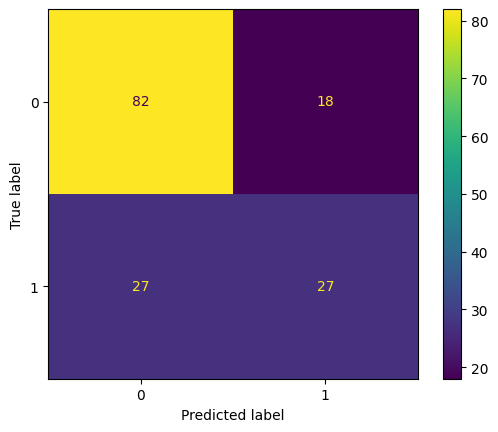

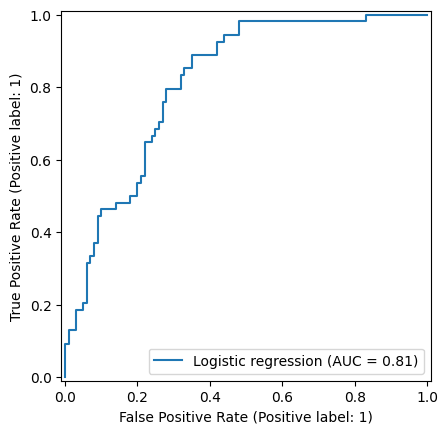

In [9]:
logit = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=SEED),
)
logit.fit(X_train, y_train)

logit_pred = logit.predict(X_test)
logit_score = logit.predict_proba(X_test)[:, 1]

print(classification_report(y_test, logit_pred, digits=3))
print("ROC AUC:", roc_auc_score(y_test, logit_score))

ConfusionMatrixDisplay.from_predictions(y_test, logit_pred)
plt.show()

RocCurveDisplay.from_predictions(y_test, logit_score, name="Logistic regression")
plt.show()

## 6. SVM with different kernels

Build SVM pipelines using:

- linear kernel;
- RBF kernel.

Both pipelines should contain median imputation and standardization.

Compare their test performance using the same metrics as above.

In [10]:
results = {}

for kernel in ["linear", "rbf"]:
    model = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        SVC(kernel=kernel, probability=True, random_state=SEED),
    )
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    score = model.predict_proba(X_test)[:, 1]

    results[kernel] = {
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, score),
    }

pd.DataFrame(results).T

,accuracy,precision,recall,f1,roc_auc
linear,0.701299,0.590909,0.481481,0.530612,0.813148
rbf,0.740260,0.652174,0.555556,0.600000,0.796389


## 7. Hyperparameter tuning — training data only

Use `GridSearchCV` on an SVM pipeline.

Explore at least:

```python
C = [0.1, 1, 10, 100]
kernel = ["linear", "rbf"]
gamma = ["scale", 0.01, 0.1, 1]
```

Use 5-fold cross-validation and `roc_auc` as the primary tuning metric.

Do **not** use `X_test` or `y_test` while choosing hyperparameters.

In [11]:
svm_pipe = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    SVC(probability=True, random_state=SEED),
)

param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__kernel": ["linear", "rbf"],
    "svc__gamma": ["scale", 0.01, 0.1, 1],
}

search = GridSearchCV(
    svm_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
)

search.fit(X_train, y_train)

print("best parameters:", search.best_params_)
print("best CV ROC AUC:", search.best_score_)

best parameters: {'svc__C': 1, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
best CV ROC AUC: 0.8431644518272424


## 8. Final evaluation

Evaluate the selected SVM once on the test set.

Compare:

- dummy baseline;
- logistic regression;
- tuned SVM.

Which model would you retain **for this exercise**, and why?

Do not answer only from accuracy. Discuss the error type that seems most important.

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Dummy,0.649351,0.000000,0.000000,0.000000,NaN
Logistic regression,0.707792,0.600000,0.500000,0.545455,0.812963
Tuned SVM,0.707792,0.609756,0.462963,0.526316,0.805185


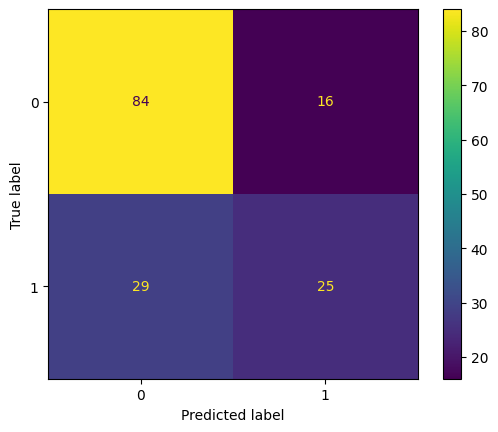

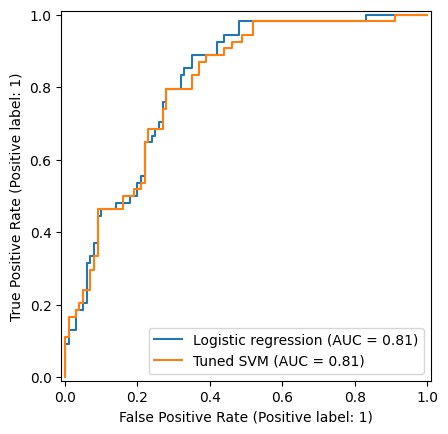

In [12]:
best_svm = search.best_estimator_
svm_pred = best_svm.predict(X_test)
svm_score = best_svm.predict_proba(X_test)[:, 1]

def metric_row(name, y_pred, y_score=None):
    row = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }
    if y_score is not None:
        row["roc_auc"] = roc_auc_score(y_test, y_score)
    return row

comparison = pd.DataFrame([
    metric_row("Dummy", dummy_pred),
    metric_row("Logistic regression", logit_pred, logit_score),
    metric_row("Tuned SVM", svm_pred, svm_score),
]).set_index("model")

display(comparison)

ConfusionMatrixDisplay.from_predictions(y_test, svm_pred)
plt.show()

RocCurveDisplay.from_predictions(y_test, logit_score, name="Logistic regression")
RocCurveDisplay.from_predictions(y_test, svm_score, name="Tuned SVM", ax=plt.gca())
plt.show()

## 9. Reflection

Answer briefly:

1. Why is fitting `StandardScaler()` on the full dataset before splitting a form of leakage?
2. Why should ROC AUC be computed from probabilities or decision scores rather than hard class predictions?
3. If the clinical objective required sensitivity ≥ 0.90, what additional step would be needed?